# K Means Color Quantization

### Imports


In [1]:
import numpy as np

import matplotlib.image as mpimg  # image processing library!
import matplotlib.pyplot as plt   # plotting deel matplotlib

matplotlib.image.imread is een functie in de matplotlib bibliotheek in Python, die wordt gebruikt om een afbeelding in te laden van een bestand in een array. Deze functie leest de afbeelding in en converteert deze naar een NumPy-array, die vervolgens kan worden gebruikt voor beeldverwerking of visualisatie.

Enkele belangrijke punten over matplotlib.image.imread:

Ondersteunde formaten: De functie ondersteunt verschillende afbeeldingsformaten, zoals PNG, JPG, BMP, en GIF. De exacte ondersteuning kan afhangen van de achterliggende bibliotheken die matplotlib gebruikt voor het inlezen van afbeeldingen.

Kleurindeling: In tegenstelling tot OpenCV, die standaard de BGR-kleurindeling gebruikt, leest matplotlib.image.imread afbeeldingen in de RGB-indeling in (Rood, Groen, Blauw).

Gebruiksgemak: Deze functie is geïntegreerd met andere matplotlib functionaliteiten, waardoor het gemakkelijk is om de ingeladen afbeeldingen direct te visualiseren met matplotlib.pyplot.

Datastructuur: **De uitvoer van imread is een NumPy-array, waardoor deze gemakkelijk te manipuleren is met standaardarray-operaties in Python.**

Deze functie is vooral handig voor eenvoudige beeldverwerkingsopdrachten en voor de visualisatie van afbeeldingen als onderdeel van data-analyse en grafische weergaven. Voor meer geavanceerde beeldverwerking is een gespecialiseerde bibliotheek zoals OpenCV meestal geschikter.

### De afbeelding

In [2]:
image_as_array = mpimg.imread('data/sea.jpg')
# .jpg of .png rechtstreeks naar numpy array!

In [3]:
image_as_array 
# RGB CODES VOOR ELKE PIXEL
# let op [[[ : 3D - array!

array([[[  8,  39,  42],
        [  9,  40,  45],
        [ 10,  43,  50],
        ...,
        [ 11,  56,  77],
        [ 13,  65,  86],
        [ 11,  69,  89]],

       [[  0,  33,  39],
        [  1,  36,  42],
        [  4,  41,  49],
        ...,
        [ 28,  92, 127],
        [ 29,  97, 132],
        [ 27,  97, 133]],

       [[  4,  44,  52],
        [  4,  44,  52],
        [  4,  44,  52],
        ...,
        [ 30, 104, 143],
        [ 27,  96, 138],
        [ 20,  89, 131]],

       ...,

       [[ 38, 116, 152],
        [ 41, 121, 156],
        [ 42, 125, 159],
        ...,
        [ 39, 119, 154],
        [ 38, 118, 153],
        [ 36, 116, 149]],

       [[ 39, 117, 153],
        [ 42, 122, 157],
        [ 43, 125, 162],
        ...,
        [ 41, 121, 156],
        [ 39, 119, 154],
        [ 37, 117, 150]],

       [[ 35, 115, 150],
        [ 39, 119, 154],
        [ 39, 123, 159],
        ...,
        [ 38, 118, 153],
        [ 36, 116, 151],
        [ 34, 114, 147]]

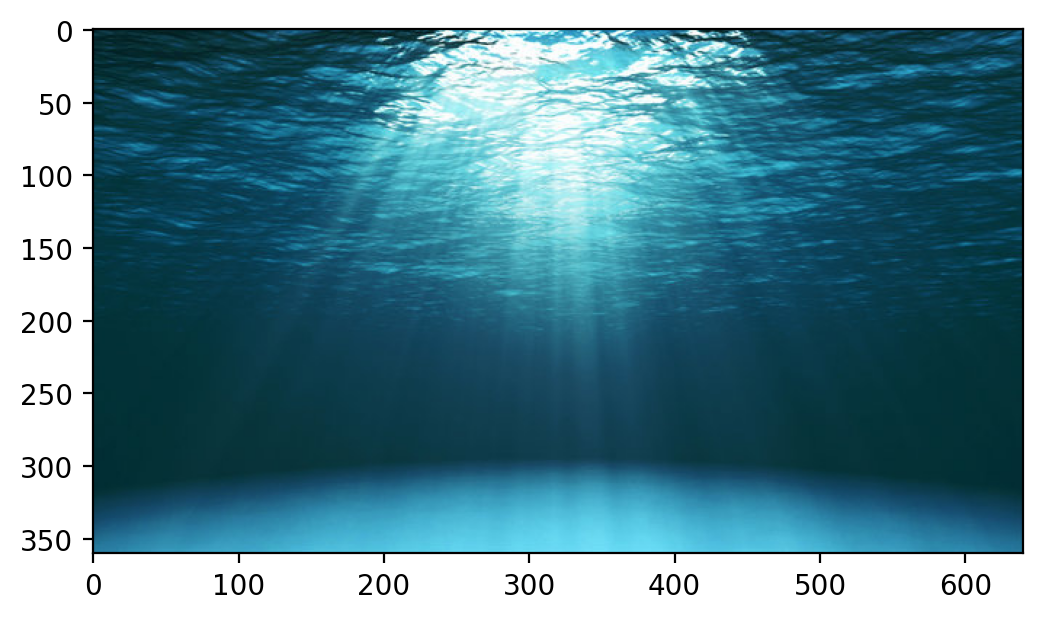

In [4]:
plt.figure(figsize=(6,6), dpi=200)
plt.imshow(image_as_array) 
# plt.imshow kan niet direct een afbeelding displayen, wel op basis van een array

## Gebruik Kmeans voor de reductie van het aantal kleuren (Color Quantization)

We reduceren het aantal kleuren tot 6

In [5]:
image_as_array.shape
# (h,w,3 kleurkanalen: R, G, B)

(360, 640, 3)

### Converteer van 3d naar 2d


Kmeans is ontworpen om te trainen op 2D data: rijen van feature kolommen.  Daarom gaan we de data reshapen van (h,w,c) ---> (h * w,c)

In [6]:
(h,w,c) = image_as_array.shape # tuple unpacking!

In [7]:
image_as_array2d = image_as_array.reshape(h*w,c) 
# nu hebben we h*w rijen met c kolommen - één voor elk kleurkanaal!

In [8]:
from sklearn.cluster import KMeans

In [9]:
model = KMeans(n_clusters=48, n_init='auto')

In [15]:
model

KMeans(n_clusters=48, n_init='auto')

In [10]:
labels = model.fit_predict(image_as_array2d)

In [11]:
labels

array([26, 26, 26, ..., 36, 36, 27], shape=(230400,), dtype=int32)

In [12]:
# DIT ZIJN DE 6 RGB KLEURCODES!
model.cluster_centers_

array([[ 13.14329159,  76.75778175, 104.97799642],
       [ 78.09269028, 189.34702336, 217.73436323],
       [190.864983  , 237.64594463, 240.53326858],
       [ 40.2903525 , 129.20802412, 160.85273655],
       [  5.19623641,  51.48996918,  58.06240199],
       [ 31.50155709, 100.32750865, 129.52941176],
       [146.03797468, 211.88802337, 217.37487829],
       [ 74.37174721, 173.08302354, 189.18876497],
       [ 10.22502485,  58.3216327 ,  72.90724404],
       [249.69735877, 252.07006603, 252.36610418],
       [104.22355769, 217.48317308, 240.54487179],
       [ 57.78018076, 159.62976114, 190.91252421],
       [230.91449426, 249.3649635 , 250.31126173],
       [ 22.75911844,  83.513726  , 112.82123985],
       [ 14.81647016,  61.73521616,  77.94287542],
       [ 36.54860746, 111.09125941, 139.18462077],
       [ 45.40729888, 140.02051145, 170.9283431 ],
       [108.37098765, 210.27469136, 220.73395062],
       [ 10.67153482,  68.33847194,  92.9035835 ],
       [120.11937557, 200.75298

Deze cluster centers zijn gemiddelden en dus floats.  We kunnen deze waarden dus beter afronden tot integers.

In [13]:
rgb_codes = model.cluster_centers_.round(0).astype(int)
# afronden tot 0 na de komma, type cast naar int.

In [14]:
rgb_codes

array([[ 13,  77, 105],
       [ 78, 189, 218],
       [191, 238, 241],
       [ 40, 129, 161],
       [  5,  51,  58],
       [ 32, 100, 130],
       [146, 212, 217],
       [ 74, 173, 189],
       [ 10,  58,  73],
       [250, 252, 252],
       [104, 217, 241],
       [ 58, 160, 191],
       [231, 249, 250],
       [ 23,  84, 113],
       [ 15,  62,  78],
       [ 37, 111, 139],
       [ 45, 140, 171],
       [108, 210, 221],
       [ 11,  68,  93],
       [120, 201, 209],
       [ 85, 186, 199],
       [171, 235, 240],
       [ 65, 161, 179],
       [151, 227, 233],
       [ 18,  93, 123],
       [ 70, 179, 209],
       [  3,  47,  52],
       [ 29, 120, 150],
       [ 23,  77, 104],
       [210, 244, 246],
       [ 10,  55,  62],
       [ 20,  71,  95],
       [ 94, 208, 234],
       [ 51, 135, 157],
       [ 63, 170, 200],
       [ 29,  91, 120],
       [ 41, 121, 149],
       [  7,  55,  68],
       [ 96, 197, 209],
       [ 57, 149, 169],
       [  8,  62,  82],
       [112, 169

Hoe kunnen we nu de originele waarden in de array vervangen door de 6 kleuren die we nu hebben?
De labels zijn gekoppeld aan deze rgb_codes. Label code 0 is het eerste kleur in de rgb_codes!

In [15]:
labels

array([26, 26, 26, ..., 36, 36, 27], shape=(230400,), dtype=int32)

In [16]:
rgb_codes[labels]

array([[  3,  47,  52],
       [  3,  47,  52],
       [  3,  47,  52],
       ...,
       [ 41, 121, 149],
       [ 41, 121, 149],
       [ 29, 120, 150]], shape=(230400, 3))

Wat we hierboven zien is gebaseerd op de indexeringseigenschappen van NumPy-arrays.  In Numpy kan je namelijk een array indexeren met een andere array of lijst van indices.  Dit is een vorm van 'fancy indexing' waarbij je meerdere elementen tegelijk kan selecteren.  Een voorbeeld:

In [17]:
text_codes = np.array(['i', 'k', ' ', 'b', 'e', 'n', 'h', 'r', 't'])
l = np.array([0, 1, 2, 3, 4, 5, 2, 6, 0, 4, 7, 2, 5, 0, 4, 8])

result = text_codes[l]
print(''.join(result))

ik ben hier niet


In [18]:
rgb_codes[labels].shape

(230400, 3)

In [19]:
# recall: onze afbeelding was 360 * 640 pixels
360*640

230400

Dit betekent dat we nu een array hebben met alle individuele pixels, maar per pixel de rgb_code die aan het centrum van de cluster is toegewezen.  We moeten dit nu reshapen om terug een afbeelding te krijgen

In [20]:
quantized_image = np.reshape(rgb_codes[labels], (h, w, c))

 Seaborn kan op automatische wijze hierarchisch clusteren via de clustermap() functie. Maak een clustermap van de correlaties tussen alle kolommen met behulp van deze functie.quantized_image

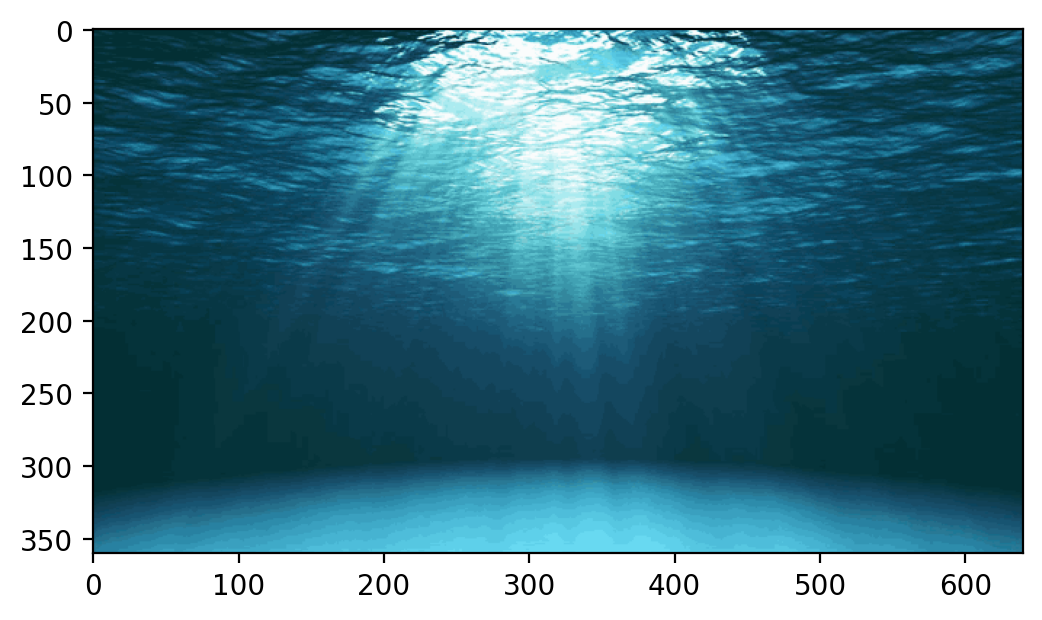

In [21]:
plt.figure(figsize=(6,6),dpi=200)
plt.imshow(quantized_image)